## Objetivo do projeto : Prever se uma pessoa pode ter diabetes com base em alguns dados padrões históricos, com uma acurácia de 70%.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# coletar os dados e entender o dataframe

df = pd.read_csv('pima-data.csv')

In [3]:
df.head()

,num_preg,glucose_conc,diastolic_bp,thickness,insulin,bmi,diab_pred,age,skin,diabetes
0,6,148,72,35,0,33.6,0.627,50,1.3780,True
1,1,85,66,29,0,26.6,0.351,31,1.1426,False
2,8,183,64,0,0,23.3,0.672,32,0.0000,True
3,1,89,66,23,94,28.1,0.167,21,0.9062,False
4,0,137,40,35,168,43.1,2.288,33,1.3790,True


In [4]:
df.columns

Index(['num_preg', 'glucose_conc', 'diastolic_bp', 'thickness', 'insulin',
       'bmi', 'diab_pred', 'age', 'skin', 'diabetes'],
      dtype='object')

In [5]:
# vericar o tipo dos dados

df.dtypes

num_preg          int64
glucose_conc      int64
diastolic_bp      int64
thickness         int64
insulin           int64
bmi             float64
diab_pred       float64
age               int64
skin            float64
diabetes           bool
dtype: object

In [6]:
# converter o tipo bool para numérico devido ao modelo

apply_map = {True : 1, False : 0}

In [7]:
df['diabetes'] = df['diabetes'].map(apply_map)

In [8]:
df.head(2)

,num_preg,glucose_conc,diastolic_bp,thickness,insulin,bmi,diab_pred,age,skin,diabetes
0,6,148,72,35,0,33.6,0.627,50,1.3780,1
1,1,85,66,29,0,26.6,0.351,31,1.1426,0


In [9]:
# verificar possivéis valores nulos

df.isnull().values.any()

False

In [10]:
# não possui (NAN-missing values) porém 0 pode ser considerado nulo também para algumas variáveis

### Vou vefificar as variáveis preditoras (importantes) para o resultado final (target)

In [11]:
# antes verifico se existem correlações

def plot_corr(df, size=10):
    corr = df.corr()
    fig, ax = plt.subplots(figsize= (size, size))
    ax.matshow(corr)
    plt.xticks(range(len(corr.columns)), corr.columns)
    plt.yticks(range(len(corr.columns)), corr.columns)

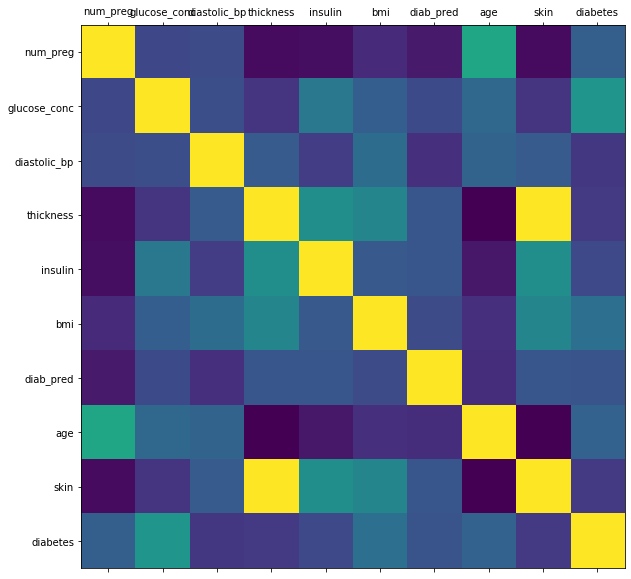

In [12]:
plot_corr(df)

In [13]:
df.corr()

,num_preg,glucose_conc,diastolic_bp,thickness,insulin,bmi,diab_pred,age,skin,diabetes
num_preg,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,-0.081673,0.221898
glucose_conc,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.057326,0.466581
diastolic_bp,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.207371,0.065068
thickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,1.000000,0.074752
insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.436785,0.130548
bmi,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.392574,0.292695
diab_pred,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.183927,0.173844
age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,-0.113973,0.238356
skin,-0.081673,0.057326,0.207371,1.000000,0.436785,0.392574,0.183927,-0.113973,1.000000,0.074750
diabetes,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,0.074750,1.000000


In [14]:
# defini as variáveis preditoras - Features

atributes = ['num_preg','glucose_conc', 'diastolic_bp', 'thickness', 'insulin', 'bmi', 'diab_pred', 'age']

target = ['diabetes']

### Agora vou aplicar a correção dos missing values (valor 0) - mas somente nos subsets de Treinamento e de Teste

In [15]:
from sklearn.model_selection import train_test_split

In [16]:
X = df[atributes].values

Y = df[target].values

In [17]:
# verificar o tamaho do data set
df.shape

(768, 10)

In [18]:
# com isso posso definir o tamanho do data set de teste

split_test_size = 0.30

In [19]:
# dividir os splits Teste e Trainamento

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = split_test_size, random_state = 42)

In [20]:
# verificar se a divisão está certa - desejada em relação ao dataSet total

print('Dados de treinamento: {0:0.2f}%'.format((len(X_train) / len(df.index)) * 100))
print('Dados de teste: {0:0.2f}%'.format((len(X_test) / len(df.index)) * 100))

Dados de treinamento: 69.92%
Dados de teste: 30.08%


In [21]:
# verificar a proporção de valores True e False dentro do Test_split e do Train_split

# A proporção de valores True e Falses deve ser mantida próxima do DataSet Original

print('DataSet original True: {0} ({1:0.2f}%)'.format(len(df.loc[df['diabetes'] == 1]), 
                                                     (len(df.loc[df['diabetes'] == 1])/len(df.index) * 100)))

print('DataSet original False: {0} ({1:0.2f}%)'.format(len(df.loc[df['diabetes'] == 0]), 
                                                     (len(df.loc[df['diabetes'] == 0])/len(df.index) * 100)))
print('')
print('Treinamento True : {0} ({1:0.2f}%)'.format(len(Y_train[Y_train[:] == 1]), 
                                               (len(Y_train[Y_train[:] == 1])/len(Y_train) * 100)))

print('Treinamento False : {0} ({1:0.2f}%)'.format(len(Y_train[Y_train[:] == 0]), 
                                               (len(Y_train[Y_train[:] == 0])/len(Y_train) * 100)))
print('')
print('Teste True : {0} ({1:0.2f}%)'.format(len(Y_test[Y_test[:] == 1]), 
                                               (len(Y_test[Y_test[:] == 1])/len(Y_test) * 100)))

print('Teste False : {0} ({1:0.2f}%)'.format(len(Y_test[Y_test[:] == 0]), 
                                               (len(Y_test[Y_test[:] == 0])/len(Y_test) * 100)))

DataSet original True: 268 (34.90%)
DataSet original False: 500 (65.10%)

Treinamento True : 188 (35.01%)
Treinamento False : 349 (64.99%)

Teste True : 80 (34.63%)
Teste False : 151 (65.37%)


In [22]:
# Agora vou tratar os missing values dentro do Training DataSEt e e Test DataSet apenas

# Pois algumas variáveis preditoras - (Features) não podem conter 0

In [23]:
print(atributes)

['num_preg', 'glucose_conc', 'diastolic_bp', 'thickness', 'insulin', 'bmi', 'diab_pred', 'age']


In [24]:
print('Linhas missing values em num_preg: {0}'.format(len(df.loc[df['num_preg'] == 0])))
print('Linhas missing values em glucose_conc: {0}'.format(len(df.loc[df['glucose_conc'] == 0])))
print('Linhas missing values em diastolic_bp: {0}'.format(len(df.loc[df['diastolic_bp'] == 0])))
print('Linhas missing values em thickness: {0}'.format(len(df.loc[df['thickness'] == 0])))
print('Linhas missing values em insulin: {0}'.format(len(df.loc[df['insulin'] == 0])))
print('Linhas missing values em bmi: {0}'.format(len(df.loc[df['bmi'] == 0])))
print('Linhas missing values em age: {0}'.format(len(df.loc[df['age'] == 0])))

Linhas missing values em num_preg: 111
Linhas missing values em glucose_conc: 5
Linhas missing values em diastolic_bp: 35
Linhas missing values em thickness: 227
Linhas missing values em insulin: 374
Linhas missing values em bmi: 11
Linhas missing values em age: 0


In [25]:
# nesse caso é melhor substituir pela média

# vou utilizar o modulo SimpleImputer para tratar os missing data

from sklearn.impute import SimpleImputer

In [26]:
imputer = SimpleImputer(missing_values=0, strategy='mean')

In [27]:
# vou transformar os dados de treinamento

# lembrando que são somente os valores de X, a saída Y se mantém

imputer = imputer.fit(X_train)
X_train = imputer.transform(X_train)

In [28]:
imputer = imputer.fit(X_test)
X_test = imputer.transform(X_test)

In [29]:
print(X_train)

[[  1.          95.          60.         ...  23.9          0.26
   22.        ]
 [  5.         105.          72.         ...  36.9          0.159
   28.        ]
 [  4.34056399 135.          68.         ...  42.3          0.365
   24.        ]
 ...
 [ 10.         101.          86.         ...  45.6          1.136
   38.        ]
 [  4.34056399 141.          72.24131274 ...  42.4          0.205
   29.        ]
 [  4.34056399 125.          96.         ...  22.5          0.262
   21.        ]]


## Construindo e treinando o modelo com machine learning

In [30]:
# lembrando que não é um problema de regressão..

# Vamos aplicar o Naive Bayes

from sklearn.naive_bayes import GaussianNB

In [31]:
# criar uma nova instância do modelo

model_v1 = GaussianNB()

In [32]:
# treinar o modelo fit()

model_v1.fit(X_train, Y_train.ravel())

GaussianNB(priors=None, var_smoothing=1e-09)

## Vefificando a exatidão (acurácia) do modelo nos dados de Treino metrics

In [33]:
nb_predict = model_v1.predict(X_train)

In [34]:
from sklearn import metrics

In [35]:
print('Accuracy : {0:.4f}'.format(metrics.accuracy_score(Y_train, nb_predict)))
print()

Accuracy : 0.7542



## Vefificando a exatidão (acurácia) do modelo nos dados de Teste metrics

In [36]:
nb_predict_test = model_v1.predict(X_test)

In [37]:
print('Accuracy : {0:.4f}'.format(metrics.accuracy_score(Y_test, nb_predict_test)))
print()

Accuracy : 0.7359



## Optimizando a precisão do modelo com Algoritimos Random Forest (ensemble)

In [38]:
from sklearn.ensemble import RandomForestClassifier

In [39]:
model_v2 = RandomForestClassifier(random_state = 42)

In [40]:
model_v2.fit(X_train, Y_train.ravel())

RandomForestClassifier(bootstrap=True, ccp_alpha=0.0, class_weight=None,
                       criterion='gini', max_depth=None, max_features='auto',
                       max_leaf_nodes=None, max_samples=None,
                       min_impurity_decrease=0.0, min_impurity_split=None,
                       min_samples_leaf=1, min_samples_split=2,
                       min_weight_fraction_leaf=0.0, n_estimators=100,
                       n_jobs=None, oob_score=False, random_state=42, verbose=0,
                       warm_start=False)

In [41]:
# verificar a acurácia para treino

rf_predict_train = model_v2.predict(X_train)

In [42]:
print('Train accuracy: {0:.4f}'.format(metrics.accuracy_score(Y_train, rf_predict_train)))
print('')

Train accuracy: 1.0000



### Uma acurácia de 100% indica Overfiting pois o modelo já foi treinado antes com os dados de treinamento

In [43]:
# devemos considerar a acurácia obtida com os dados de teste

rf_predict_test = model_v2.predict(X_test)

print('Teste accuracy: {0:.4f}'.format(metrics.accuracy_score(Y_test, rf_predict_test)))
print('')

Teste accuracy: 0.7403



## Vamos testar mais um modelo classificador LogisticRegression

In [44]:
from sklearn.linear_model import LogisticRegression

In [45]:
model_v3 = LogisticRegression(C = 0.7, random_state = 42)

In [46]:
model_v3.fit(X_train, Y_train.ravel())

C:\Users\abner\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:940: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  extra_warning_msg=_LOGISTIC_SOLVER_CONVERGENCE_MSG)


LogisticRegression(C=0.7, class_weight=None, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=100,
                   multi_class='auto', n_jobs=None, penalty='l2',
                   random_state=42, solver='lbfgs', tol=0.0001, verbose=0,
                   warm_start=False)

In [47]:
lr_predict_test = model_v3.predict(X_test)

In [48]:
print('Acurácia : {0:.4f}'.format(metrics.accuracy_score(Y_test, lr_predict_test)))
print('')

Acurácia : 0.7489



In [49]:
# O modelo que apresentou a melhor acurácia foi o LinearRegression, sendo 74,89% de precisão.

## Salvando o modelo antes de colocar em produção

In [50]:
# posso salvar o meu modelo com joblib ou pickle

In [51]:
import pickle

In [52]:
# salvar o modelo com um nome

filename = 'modelo_treinado_v3.sav'
pickle.dump(model_v3, open(filename, 'wb'))

In [53]:
# uma vez que eu salvei o modelo posso carregar ele fazer previsões

loaded_model = pickle.load(open(filename, 'rb'))

In [54]:
# vou prever alguns resultados
# prevendo o elemendo 15

result_1 = loaded_model.predict(X_test[15].reshape(1, -1))

In [55]:
result_2 = loaded_model.predict(X_test[18].reshape(1, -1))

In [56]:
print(result_1)
print(result_2)

[0]
[1]


In [57]:
# para salvar um conjunto de dados muito grande o joblib é mais eficiente

import joblib

In [58]:
joblib.dump(model_v3, 'model_joblib.sav')

['model_joblib.sav']

In [59]:
loaded_joblib_model = joblib.load('model_joblib.sav')

In [60]:
result01 = loaded_joblib_model.predict(X_test[15].reshape(1,-1))

In [61]:
result02 = loaded_joblib_model.predict(X_test[18].reshape(1, -1))

In [62]:
print(result01)
print(result02)

[0]
[1]
